PARTE 1

In [ ]:
!pip install seaborn

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
#importo las bases de datos, t1_24 y t1_25

df1 = pd.read_excel("usu_individual_T125.xlsx")

df2 = pd.read_excel("usu_individual_T124.xlsx")

In [63]:
#selecciono columnas a analizar

t1_25= df1[["CODUSU", "ANO4", "TRIMESTRE", "NRO_HOGAR", "PONDERA", "CH04", "CH06", "CH07", "CH08", "NIVEL_ED", "ESTADO", "CAT_OCUP", "EMPLEO", "SECTOR", "PP04C", "PP04D_COD", "P21", "P47T", "PP04G", "PP04A"]]
t1_24= df2[["CODUSU", "ANO4", "TRIMESTRE", "NRO_HOGAR", "PONDERA", "CH04", "CH06", "CH07", "CH08", "NIVEL_ED", "ESTADO", "CAT_OCUP", "EMPLEO", "SECTOR", "PP04C", "PP04D_COD", "P21", "P47T", "PP04G", "PP04A"]]

t1_25.info()

<class 'pandas.DataFrame'>
RangeIndex: 45425 entries, 0 to 45424
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   CODUSU     45425 non-null  str    
 1   ANO4       45425 non-null  int64  
 2   TRIMESTRE  45425 non-null  int64  
 3   NRO_HOGAR  45425 non-null  int64  
 4   PONDERA    45425 non-null  int64  
 5   CH04       45425 non-null  int64  
 6   CH06       45425 non-null  int64  
 7   CH07       45425 non-null  int64  
 8   CH08       45424 non-null  float64
 9   NIVEL_ED   45425 non-null  int64  
 10  ESTADO     45425 non-null  int64  
 11  CAT_OCUP   45425 non-null  int64  
 12  EMPLEO     20076 non-null  float64
 13  SECTOR     20076 non-null  float64
 14  PP04C      20076 non-null  float64
 15  PP04D_COD  20076 non-null  float64
 16  P21        45425 non-null  int64  
 17  P47T       45350 non-null  float64
 18  PP04G      20076 non-null  float64
 19  PP04A      20076 non-null  float64
dtypes: float64(8), in

Las columnas 12, 13, 14, 15, 18 y 19 con una significativa cantidad de valores nulos.

In [17]:
t1_25.to_excel("t1_25_eph.xlsx", index=False)

In [18]:
t1_24.to_excel("t1_24_eph.xlsx", index=False)

Chequeo de valores negativos en colummnas de ingresos y edad. Para la edad del encuestado no hay ningun codigo que signifique que no contestó

In [64]:
# definir las columnas a evaluar
posibles_neg = ["P21", "P47T", "CH06"]

# variables que agrupan los valores negativos de las columnas
cont_neg_25 = t1_25[posibles_neg] < 0
cont_neg_24 = t1_24[posibles_neg] < 0


print(cont_neg_25.sum())
print(cont_neg_24.sum())

P21     3839
P47T    5405
CH06     290
dtype: int64
P21     3403
P47T    4862
CH06     334
dtype: int64


In [65]:
# reemplazar negativos por NaN en ambos dataframes
t1_25[posibles_neg] = t1_25[posibles_neg].where(t1_25[posibles_neg] >= 0, np.nan) #función where, marca como condición los valores mayores o 
t1_24[posibles_neg] = t1_24[posibles_neg].where(t1_24[posibles_neg] >= 0, np.nan) #iguales a 0, y en caso de ser falso lo transforma a NaN

In [66]:
# variables que agrupan los valores negativos de las columnas
cont_neg_25 = t1_25[posibles_neg] < 0
cont_neg_24 = t1_24[posibles_neg] < 0

print(cont_neg_25.sum())
print(cont_neg_24.sum())

P21     0
P47T    0
CH06    0
dtype: int64
P21     0
P47T    0
CH06    0
dtype: int64


Genero un heatmap con porcentajes de valores nulos T1 25

In [76]:
# cambio nombres de columnas
t1_25.columns = ["CODIGO", "AÑO", "TRIM", "NRO_HOGAR", "PONDERA", "SEXO", "EDAD", "EST. CIVIL", "COB. MEDICA", "NIVEL ED.", "ESTADO", "CAT. OCUP.", "INFORMALIDAD", "SECTOR", "Nª TRABAJADORES", "COD_OCUP", "ING. PRINCIPAL", "ING. TOTAL", "LUGAR LAB.", "ESTATAL/ PRIVADO/ OTRO" ]
t1_24.columns = ["CODIGO", "AÑO", "TRIM", "NRO_HOGAR", "PONDERA", "SEXO", "EDAD", "EST. CIVIL", "COB. MEDICA", "NIVEL ED.", "ESTADO", "CAT. OCUP.", "INFORMALIDAD", "SECTOR", "Nª TRABAJADORES", "COD_OCUP", "ING. PRINCIPAL", "ING. TOTAL", "LUGAR LAB.", "ESTATAL/ PRIVADO/ OTRO" ]

In [77]:
#creo variable que muestre el porcentaje de nulos por columna
#es un dataframe binario donde si es NaN, se transforma en 1. Para 
nan_col = pd.DataFrame([t1_25.isnull().mean() * 100], index=["% NaN"])

In [78]:
#elimino variables de identificación 
nan_col = nan_col.drop(columns=["CODIGO", "AÑO", "TRIM", "NRO_HOGAR", "PONDERA"])

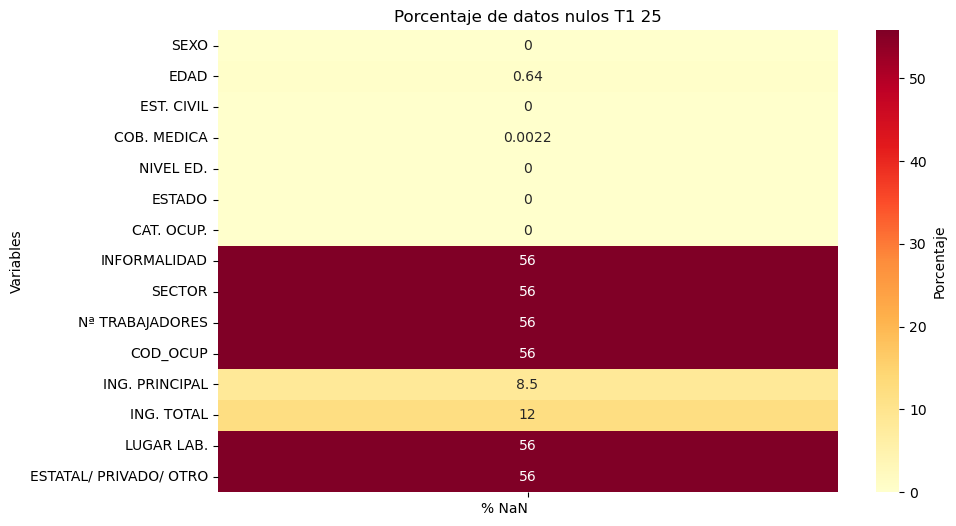

In [79]:
# creo el heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(nan_col.T, annot=True, cmap="YlOrRd",cbar_kws={'label': 'Porcentaje'})
plt.title("Porcentaje de datos nulos T1 25")
plt.xticks(rotation=0, ha='right')
plt.ylabel("Variables")
plt.yticks(rotation=0)
plt.show()

Genero un heatmap con porcentajes de valores nulos T1 24

In [80]:
# repito proceso anterior
nan_col_24 = pd.DataFrame([t1_24.isnull().mean() * 100], index=["% NaN"])

nan_col_24 = nan_col_24.drop(columns=["CODIGO", "AÑO", "TRIM", "NRO_HOGAR", "PONDERA"])

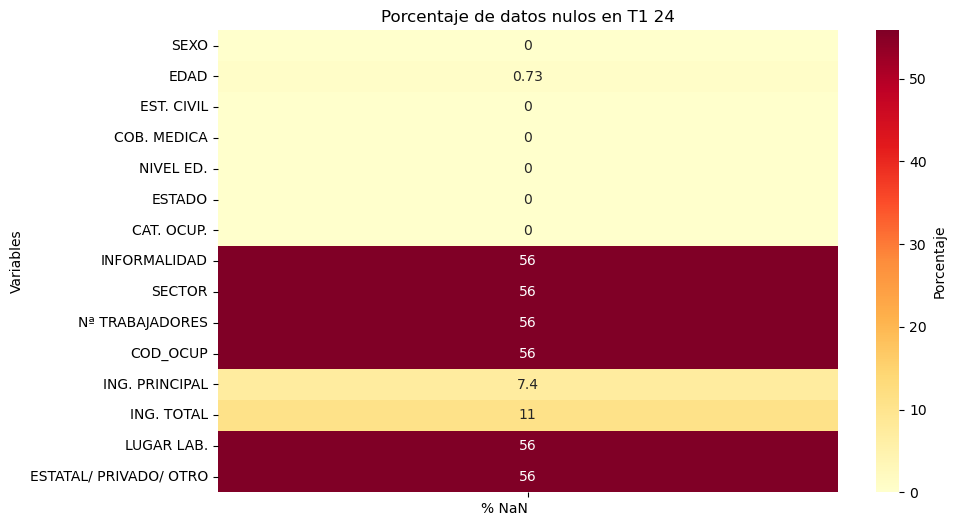

In [81]:
# creo el heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(nan_col_24.T, annot=True, cmap="YlOrRd",cbar_kws={'label': 'Porcentaje'})
plt.title("Porcentaje de datos nulos en T1 24")
plt.xticks(rotation=0, ha='right')
plt.ylabel("Variables")
plt.yticks(rotation=0)
plt.show()

Variable dicotómica para la variable "Sexo". Varón = 0, Mujer = 1

In [82]:
t1_25["SEXO"] = t1_25["SEXO"] - 1
t1_24["SEXO"] = t1_24["SEXO"] - 1

Multiplico el cociente "de ipc mar25/ ipc mar24" a las columnas "ing principal" y "ing total"

In [83]:
mult = round(8353.3 / 5357.1, 2)
mult

1.56

In [61]:
#datos de ingresos de 1t24 se pasan a valores de 1t25
#t1_24["ING. PRINCIPAL", "ING. TOTAL"] = t1_24["ING. PRINCIPAL" * mult, "ING. TOTAL" * mult]

In [75]:
t1_24["ING. PRINCIPAL"] = pd.to_numeric(t1_24["ING. PRINCIPAL"]) * mult
t1_24["ING. TOTAL"] = pd.to_numeric(t1_24["ING. TOTAL"]) * mult

t1_24.head()

,CODIGO,AÑO,TRIM,NRO_HOGAR,PONDERA,SEXO,EDAD,EST. CIVIL,COB. MEDICA,NIVEL ED.,EST. LAB,CAT. OCUP.,INFORMALIDAD,SECTOR,Nª TRABAJADORES,COD_OCUP,ING. PRINCIPAL,ING. TOTAL,LUGAR LAB.,ESTATAL/ PRIVADO/ OTRO
0,TQRMNOSTSHJOLOCDEHLEH00795168,2024,1,1,140,1,86.0,4,1,2,3,0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
1,TQRMNOSQYHJMLPCDEIKAH00793199,2024,1,1,648,0,68.0,3,1,2,1,2,2.0,2.0,1.0,72113.0,234000.0,436800.0,8.0,2.0
2,TQRMNOSQYHJMLPCDEIKAH00793199,2024,1,1,648,0,20.0,5,1,4,2,2,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN
3,TQRMNORWPHJOLLCDEGPDJ00795996,2024,1,1,281,1,75.0,3,1,6,3,0,NaN,NaN,NaN,NaN,0.0,624000.0,NaN,NaN
4,TQRMNOTQRHJMLOCDEHJGH00794657,2024,1,1,252,1,41.0,1,1,4,1,2,2.0,2.0,1.0,57113.0,390000.0,390000.0,12.0,2.0


In [ ]:
#creacion de variables para 1t25
respondieron_25 = t1_25[t1_25["ESTADO"] != 0]
norespondieron_25 = t1_25[t1_25["ESTADO"] == 0]

ocupados_25 = respondieron[respondieron["ESTADO"] == 1]

In [86]:
#creacion de variables para 1t25
respondieron_24 = t1_24[t1_24["ESTADO"] != 0]
norespondieron_24 = t1_24[t1_24["ESTADO"] == 0]

ocupados_24 = respondieron_24[respondieron_24["ESTADO"] == 1]